In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Getting different datasheets in different dataframes
df_customer = pd.read_excel(
    "customer_churn_data_raw.xlsx",
    sheet_name = 'db_customer'
)

df_subscription = pd.read_excel(
    "customer_churn_data_raw.xlsx",
    sheet_name = 'db_subscription'
)

df_support = pd.read_excel(
    "customer_churn_data_raw.xlsx",
    sheet_name = 'db_support'
)

In [4]:
df_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,NaN


In [5]:
df_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [6]:
df_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,NaN,service issue
1,0003-MKNFE,2024-08-28,Y,10,NaN,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,NaN,NaN
3,0013-MHZWF,2025-03-18,N,90,NaN,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,NaN,NaN


In [7]:
# Data Cleaning

In [8]:
# Cleaning df_customer dataset
df_customer.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode'],
      dtype='object')

In [9]:
# Rename column - name --> customer_name

In [10]:
df_customer.rename(columns = {'name' : 'customer_name'}, inplace=True)

In [11]:
df_customer.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode'],
      dtype='object')

In [12]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     521 non-null    object        
 1   customer_name  521 non-null    object        
 2   country        437 non-null    object        
 3   state          521 non-null    object        
 4   gender         521 non-null    object        
 5   dob            521 non-null    datetime64[ns]
 6   interests      106 non-null    object        
 7   pincode        0 non-null      float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 32.7+ KB


In [13]:
# Here we can see country has few null values and we need to fill those null values with exact countries.
# interest and pincode need to be dropped

In [14]:
# Dropping less importent columns - interests and pincode
df_customer.drop(columns = ['interests', 'pincode'], inplace=True)

In [15]:
df_customer.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob'], dtype='object')

In [16]:
# Filling null values of country column
df_customer[df_customer['country'].isna()].head()

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01
21,1824-AHFTR,rangadevi,NaN,Kathmandu,Women,1966-06-05
36,7177-XLGBA,amit,NaN,Kathmandu,Female,1965-04-28


In [17]:
df_customer[['state', 'country']].head()

,state,country
0,Maharashtra,India
1,Karnataka,India
2,Delhi,India
3,Nagaland,India
4,Delhi,India


In [18]:
# Before the mapping, checking whether a state always belongs to the same country in dataset
df_customer.groupby('state')['country'].unique()

state
Bihar                 [India]
Delhi            [India, nan]
Gujarat               [India]
Karnataka             [India]
Kathmandu        [nan, Nepal]
Kerala                [India]
Maharashtra           [India]
Meghalaya             [India]
Nagaland              [India]
Odisha                [India]
Punjab                [India]
Rajasthan             [India]
Tamil Nadu            [India]
Telangana        [nan, India]
Uttar Pradesh         [India]
West Bengal           [India]
Name: country, dtype: object

In [19]:
# Mapping state-column pair 
state_country_mapping = df_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_customer['country'] = df_customer['country'].fillna(df_customer['state'].map(state_country_mapping))

In [20]:
df_customer.info() # no null value presents in country column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     521 non-null    object        
 1   customer_name  521 non-null    object        
 2   country        521 non-null    object        
 3   state          521 non-null    object        
 4   gender         521 non-null    object        
 5   dob            521 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 24.5+ KB


In [21]:
df_customer['gender'].unique() # here we need to do standarization of data (male & female)

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [22]:
# Replacing Men --> Male and Women --> Female 
df_customer['gender'] = df_customer['gender'].replace({'Men':'Male', 'Women':'Female'})

In [23]:
df_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [24]:
# Cleaning df_subscription
df_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [25]:
df_subscription.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score'],
      dtype='object')

In [26]:
df_subscription.info() # here we need to change datatype of subscription_start_date, cancellation_date, renewal_date 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               521 non-null    object 
 1   subscription_start_date  521 non-null    object 
 2   subscription_type        521 non-null    object 
 3   renewal_date             521 non-null    object 
 4   plan_type                521 non-null    object 
 5   contract_type            521 non-null    object 
 6   cancellation_date        137 non-null    object 
 7   cancellation_reason      137 non-null    object 
 8   monthly_charges          521 non-null    float64
 9   cltv                     521 non-null    int64  
 10  churn_score              521 non-null    int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 44.9+ KB


In [27]:
# changing datatype of subscription_start_date, cancellation_date, renewal_date
date_col = ['subscription_start_date', 'cancellation_date', 'renewal_date']
df_subscription[date_col] = df_subscription[date_col].apply(pd.to_datetime)

In [28]:
df_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               521 non-null    object        
 1   subscription_start_date  521 non-null    datetime64[ns]
 2   subscription_type        521 non-null    object        
 3   renewal_date             521 non-null    datetime64[ns]
 4   plan_type                521 non-null    object        
 5   contract_type            521 non-null    object        
 6   cancellation_date        137 non-null    datetime64[ns]
 7   cancellation_reason      137 non-null    object        
 8   monthly_charges          521 non-null    float64       
 9   cltv                     521 non-null    int64         
 10  churn_score              521 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 44.9+ KB


In [29]:
df_subscription['subscription_type'].unique()

array(['Refferal', 'Paid', 'Organic'], dtype=object)

In [30]:
# changing 'Refferal' to 'Referral'
df_subscription['subscription_type'] = (df_subscription['subscription_type'].replace({'Refferal': 'Referral'}))

In [31]:
df_subscription['subscription_type'].unique()

array(['Referral', 'Paid', 'Organic'], dtype=object)

In [32]:
# Cleaning df_support

In [33]:
df_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,NaN,service issue
1,0003-MKNFE,2024-08-28,Y,10,NaN,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,NaN,NaN
3,0013-MHZWF,2025-03-18,N,90,NaN,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,NaN,NaN


In [34]:
df_support.info() # here col_1 and comment not needed for analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      222 non-null    object        
 1   complaint_date  222 non-null    datetime64[ns]
 2   escalations     222 non-null    object        
 3   csat_score      222 non-null    int64         
 4   col_1           0 non-null      float64       
 5   comment         141 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 10.5+ KB


In [35]:
df_support.drop(columns = ['col_1', 'comment'], inplace=True)

In [36]:
df_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [37]:
df_subscription['subscription_type'].unique()

array(['Referral', 'Paid', 'Organic'], dtype=object)

In [38]:
# df_subscription['subscription_type'] = df_subscription['subscription_type'].replace({'Refferal':'Referral'}, inplace=True)

In [39]:
# Feature Engineering

In [40]:
# Feature Engineering on df_customer
df_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [41]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     521 non-null    object        
 1   customer_name  521 non-null    object        
 2   country        521 non-null    object        
 3   state          521 non-null    object        
 4   gender         521 non-null    object        
 5   dob            521 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 24.5+ KB


In [42]:
# creating age column for every customer 
today = pd.Timestamp.today()
df_customer['age'] = today.year - df_customer['dob'].dt.year
df_customer[['dob', 'age']].head()

,dob,age
0,1982-04-12,44
1,1995-11-23,31
2,1978-02-15,48
3,2001-08-30,25
4,1990-05-05,36


In [43]:
# creating age_group column
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']

df_customer['age_group'] = pd.cut(df_customer['age'], bins=bins, labels=labels)

In [44]:
df_customer[['dob', 'age', 'age_group']].head(10)

,dob,age,age_group
0,1982-04-12,44,36-45
1,1995-11-23,31,26-35
2,1978-02-15,48,46-55
3,2001-08-30,25,18-25
4,1990-05-05,36,36-45
5,1988-12-10,38,36-45
6,1976-09-21,50,46-55
7,1999-03-14,27,26-35
8,1985-07-07,41,36-45
9,1993-10-29,33,26-35


In [45]:
df_customer['age_group'].value_counts().sort_index()

age_group
18-25     69
26-35    109
36-45    147
46-55    112
56-65     84
66+        0
Name: count, dtype: int64

In [46]:
df_customer.head()

,customerid,customer_name,country,state,gender,dob,age,age_group
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,44,36-45
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,31,26-35
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,48,46-55
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,25,18-25
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,36,36-45


In [47]:
# Feature Engineering on df_subscription
df_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [48]:
df_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               521 non-null    object        
 1   subscription_start_date  521 non-null    datetime64[ns]
 2   subscription_type        521 non-null    object        
 3   renewal_date             521 non-null    datetime64[ns]
 4   plan_type                521 non-null    object        
 5   contract_type            521 non-null    object        
 6   cancellation_date        137 non-null    datetime64[ns]
 7   cancellation_reason      137 non-null    object        
 8   monthly_charges          521 non-null    float64       
 9   cltv                     521 non-null    int64         
 10  churn_score              521 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 44.9+ KB


In [49]:
# creating churn_flag column where churned = 1 else 0
df_subscription['churn_flag'] = df_subscription['cancellation_date'].notna().astype(int)
df_subscription[['cancellation_date','churn_flag']].head(10)

,cancellation_date,churn_flag
0,NaT,0
1,2024-09-10,1
2,NaT,0
3,NaT,0
4,2024-02-28,1
5,NaT,0
6,2024-11-15,1
7,NaT,0
8,NaT,0
9,NaT,0


In [50]:
# creating tenure_days column
# those who dont have cancellation date, we take those upto today
today = pd.Timestamp.today()
df_subscription['tenure_days'] = np.where(df_subscription['cancellation_date'].notna(),
         (df_subscription['cancellation_date'] - df_subscription['subscription_start_date']).dt.days,
         (today - df_subscription['subscription_start_date']).dt.days
        )

In [51]:
df_subscription[['subscription_start_date', 'cancellation_date', 'tenure_days']].head(10)

,subscription_start_date,cancellation_date,tenure_days
0,2021-03-15,NaT,2016.0
1,2020-08-01,2024-09-10,1501.0
2,2022-11-20,NaT,1401.0
3,2019-05-10,NaT,2691.0
4,2023-01-05,2024-02-28,419.0
5,2022-06-18,NaT,1556.0
6,2021-09-30,2024-11-15,1142.0
7,2020-02-14,NaT,2411.0
8,2023-07-22,NaT,1157.0
9,2022-04-03,NaT,1632.0


In [52]:
# creating tenure_year
df_subscription['tenure_years'] = (df_subscription['tenure_days']/365.25).round(2)
df_subscription[['tenure_days', 'tenure_years']].head()

,tenure_days,tenure_years
0,2016.0,5.52
1,1501.0,4.11
2,1401.0,3.84
3,2691.0,7.37
4,419.0,1.15


In [53]:
df_subscription['tenure_years'].describe()

count    521.000000
mean       3.863858
std        2.060563
min        0.090000
25%        2.240000
50%        3.750000
75%        5.650000
max        7.700000
Name: tenure_years, dtype: float64

In [54]:
# creating tenure_group
bins = [0, 1, 3, 5, 7, float('inf')]
labels = [
    '0-1 years',
    '1-3 years',
    '3-5 years',
    '5-7 years',
    '7+ years'
]

df_subscription['tenure_group'] = pd.cut(
    df_subscription['tenure_years'],
    bins = bins,
    labels = labels,
    include_lowest = True
)

In [55]:
df_subscription[['tenure_days', 'tenure_years', 'tenure_group']].head()

,tenure_days,tenure_years,tenure_group
0,2016.0,5.52,5-7 years
1,1501.0,4.11,3-5 years
2,1401.0,3.84,3-5 years
3,2691.0,7.37,7+ years
4,419.0,1.15,1-3 years


In [56]:
# creating annual_charges column
df_subscription['annual_charges'] = df_subscription['monthly_charges'] * 12
df_subscription[['monthly_charges', 'annual_charges']].head() 

,monthly_charges,annual_charges
0,13.99,167.88
1,12.99,155.88
2,6.99,83.88
3,22.99,275.88
4,13.99,167.88


In [57]:
# creating cancellation_year column
df_subscription['cancellation_year'] = df_subscription['cancellation_date'].dt.year
df_subscription[['cancellation_date', 'cancellation_year']].head()

,cancellation_date,cancellation_year
0,NaT,NaN
1,2024-09-10,2024.0
2,NaT,NaN
3,NaT,NaN
4,2024-02-28,2024.0


In [58]:
# creating cancellation_month column
df_subscription['cancellation_month'] = df_subscription['cancellation_date'].dt.month
df_subscription[['cancellation_date','cancellation_year', 'cancellation_month']].head()

,cancellation_date,cancellation_year,cancellation_month
0,NaT,NaN,NaN
1,2024-09-10,2024.0,9.0
2,NaT,NaN,NaN
3,NaT,NaN,NaN
4,2024-02-28,2024.0,2.0


In [59]:
df_subscription['churn_score'].describe()

count    521.000000
mean      44.489443
std       28.211638
min        2.000000
25%       21.000000
50%       41.000000
75%       71.000000
max       99.000000
Name: churn_score, dtype: float64

In [60]:
# creating churn_risk_group column
bins = [0, 30, 60, 100]
labels = ['Low Risk', 'Medium Risk', 'High Risk']
df_subscription['churn_risk_group'] = pd.cut(
    df_subscription['churn_score'],
    bins=bins,
    labels=labels
)

In [61]:
df_subscription[['churn_score', 'churn_risk_group']].head()

,churn_score,churn_risk_group
0,12,Low Risk
1,91,High Risk
2,34,Medium Risk
3,8,Low Risk
4,88,High Risk


In [62]:
df_subscription.isnull().sum()

customerid                   0
subscription_start_date      0
subscription_type            0
renewal_date                 0
plan_type                    0
contract_type                0
cancellation_date          384
cancellation_reason        384
monthly_charges              0
cltv                         0
churn_score                  0
churn_flag                   0
tenure_days                  0
tenure_years                 0
tenure_group                 0
annual_charges               0
cancellation_year          384
cancellation_month         384
churn_risk_group             0
dtype: int64

In [63]:
# Feature Engineering on df_support

In [64]:
df_support['escalations'].unique()

array(['N', 'Y'], dtype=object)

In [65]:
# Mapping Y-->1 and N-->0
df_support['escalations_flag'] = df_support['escalations'].map({'Y':1, 'N':0})

In [66]:
df_support[['escalations','escalations_flag']].head(10)

,escalations,escalations_flag
0,N,0
1,Y,1
2,Y,1
3,N,0
4,N,0
5,Y,1
6,Y,1
7,Y,1
8,N,0
9,Y,1


In [67]:
# creating complaint_year column
df_support['complaint_year'] = df_support['complaint_date'].dt.year
df_support[['complaint_date', 'complaint_year']].head()

,complaint_date,complaint_year
0,2024-08-28,2024
1,2024-08-28,2024
2,2024-01-20,2024
3,2025-03-18,2025
4,2024-11-01,2024


In [68]:
# creating complaint_month column
df_support['complaint_month'] = df_support['complaint_date'].dt.month
df_support[['complaint_date', 'complaint_year', 'complaint_month']].head()

,complaint_date,complaint_year,complaint_month
0,2024-08-28,2024,8
1,2024-08-28,2024,8
2,2024-01-20,2024,1
3,2025-03-18,2025,3
4,2024-11-01,2024,11


In [69]:
df_support['csat_score'].describe()

count    222.000000
mean      36.783784
std       23.600524
min        5.000000
25%       20.000000
50%       31.000000
75%       49.750000
max       95.000000
Name: csat_score, dtype: float64

In [70]:
# creating csat_group column
bins = [0, 30, 60, 100]
labels = [
    'Low Satisfaction',
    'Medium Satisfaction',
    'High Satisfaction'
]

df_support['csat_group'] = pd.cut(
    df_support['csat_score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [71]:
df_support[['csat_score', 'csat_group']].head()

,csat_score,csat_group
0,60,Medium Satisfaction
1,10,Low Satisfaction
2,20,Low Satisfaction
3,90,High Satisfaction
4,30,Low Satisfaction


In [72]:
df_support['csat_group'].value_counts()

csat_group
Low Satisfaction       109
Medium Satisfaction     72
High Satisfaction       41
Name: count, dtype: int64

In [73]:
df_support.isnull().sum()

customerid          0
complaint_date      0
escalations         0
csat_score          0
escalations_flag    0
complaint_year      0
complaint_month     0
csat_group          0
dtype: int64

In [74]:
complaint_summary = df_support.groupby('customerid').size().reset_index(name='complaint_count')
complaint_summary.head()

,customerid,complaint_count
0,0003-MKNFE,2
1,0013-EXCHZ,1
2,0013-MHZWF,1
3,0013-SMEOE,1
4,0017-FCPNL,1


In [75]:
escalation_summary = df_support.groupby('customerid')['escalations_flag'].sum().reset_index(name='escalation_count')
escalation_summary.head(10)

,customerid,escalation_count
0,0003-MKNFE,1
1,0013-EXCHZ,1
2,0013-MHZWF,0
3,0013-SMEOE,0
4,0017-FCPNL,0
5,0017-IUDMW,1
6,0019-EFAEP,1
7,0022-TCJCI,1
8,0035-IVZHN,1
9,0049-TPBIB,1


In [76]:
# creating complaint_count column
df_support['complaint_count'] = df_support.groupby('customerid')['customerid'].transform('count')
df_support['complaint_count'].head()

0    2
1    2
2    1
3    1
4    1
Name: complaint_count, dtype: int64

In [77]:
# creating escalation_count column
df_support['escalation_count'] = df_support.groupby('customerid')['escalations_flag'].transform('sum')
df_support['escalation_count'].head()

0    1
1    1
2    1
3    0
4    0
Name: escalation_count, dtype: int64

In [78]:
df_support[
    ['customerid', 'escalations', 'escalations_flag',
     'complaint_count', 'escalation_count']
].head(10)

,customerid,escalations,escalations_flag,complaint_count,escalation_count
0,0003-MKNFE,N,0,2,1
1,0003-MKNFE,Y,1,2,1
2,0013-EXCHZ,Y,1,1,1
3,0013-MHZWF,N,0,1,0
4,0013-SMEOE,N,0,1,0
5,0017-IUDMW,Y,1,1,1
6,0019-EFAEP,Y,1,1,1
7,0022-TCJCI,Y,1,2,1
8,0022-TCJCI,N,0,2,1
9,0803-XTVXU,Y,1,1,1


In [79]:
# creating avg_csat_score column
df_support['avg_csat_score'] = df_support.groupby('customerid')['csat_score'].transform('mean')
df_support[['customerid', 'csat_score', 'avg_csat_score']].head()

,customerid,csat_score,avg_csat_score
0,0003-MKNFE,60,35.0
1,0003-MKNFE,10,35.0
2,0013-EXCHZ,20,20.0
3,0013-MHZWF,90,90.0
4,0013-SMEOE,30,30.0


In [80]:
# creating last_complaint_date column
df_support['last_complaint_date'] = df_support.groupby('customerid')['complaint_date'].transform('max')
df_support[['complaint_date', 'last_complaint_date']].head()

,complaint_date,last_complaint_date
0,2024-08-28,2024-08-28
1,2024-08-28,2024-08-28
2,2024-01-20,2024-01-20
3,2025-03-18,2025-03-18
4,2024-11-01,2024-11-01


In [81]:
df_support_customer = df_support[
    [
        'customerid',
        'complaint_count',
        'escalation_count',
        'avg_csat_score',
        'last_complaint_date'
    ]
].drop_duplicates('customerid')

In [82]:
# merging datasets into one

In [83]:
# df_customer + df_subscription
df = df_customer.merge(df_subscription, on='customerid', how='left')

In [84]:
# df + df_support_customer
df = df.merge(df_support_customer, on='customerid', how='left')

In [85]:
df.shape

(521, 30)

In [86]:
# downloading merged dataset in csv format
df.to_csv('customer_churn_merged.csv', index=False)

In [ ]:
# Uploading merged dataset in the database

In [132]:
from sqlalchemy import create_engine
username = 'root'
password = ''
host = 'localhost'
port = '3306'
database = 'customer_churn_analysis'

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")
table_name = 'customer_churn_data'

df.to_sql(table_name, engine, if_exists='replace', index=False)

#read back sample
pd.read_sql("SELECT * FROM customer_churn_data LIMIT 5;", engine)

,customerid,customer_name,country,state,gender,dob,age,age_group,subscription_start_date,subscription_type,...,tenure_years,tenure_group,annual_charges,cancellation_year,cancellation_month,churn_risk_group,complaint_count,escalation_count,avg_csat_score,last_complaint_date
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,44,36-45,2021-03-15,Referral,...,5.52,5-7 years,167.88,NaN,None,Low Risk,0.0,0.0,NaN,NaT
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,31,26-35,2020-08-01,Paid,...,4.11,3-5 years,155.88,2024.0,2024-09,High Risk,2.0,1.0,35.0,2024-08-28
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,48,46-55,2022-11-20,Organic,...,3.84,3-5 years,83.88,NaN,None,Medium Risk,0.0,0.0,NaN,NaT
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,25,18-25,2019-05-10,Paid,...,7.37,7+ years,275.88,NaN,None,Low Risk,0.0,0.0,NaN,NaT
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,36,36-45,2023-01-05,Referral,...,1.15,1-3 years,167.88,2024.0,2024-02,High Risk,1.0,1.0,20.0,2024-01-20


In [ ]:
# sql queries to analyse the data

# Q1. What is the total number of customers?
# mysql> SELECT COUNT(DISTINCT customerid) AS total_customers_number FROM customer_churn_data;
# +------------------------+
# | total_customers_number |
# +------------------------+
# |                    521 |
# +------------------------+
  
# Q2. What is the overall churn rate?
mysql> SELECT ROUND(SUM(churn_flag) * 100.0 / COUNT(*), 2) AS churn_rate FROM customer_churn_data;
+------------+
| churn_rate |
+------------+
|      26.30 |
+------------+
  
# Q3. How many customers churned by contract type?
mysql> SELECT contract_type, COUNT(customerid) AS churned_customer FROM customer_churn_data GROUP BY contract_type;
+---------------+------------------+
| contract_type | churned_customer |
+---------------+------------------+
| Annual        |              254 |
| Monthly       |              267 |
+---------------+------------------+

# Q4. What is the churn rate by subscription type?
mysql> SELECT subscription_type, ROUND(SUM(churn_flag) * 100 / COUNT(*), 2) AS churn_rate FROM customer_churn_data GROUP BY subscription_type;
+-------------------+------------+
| subscription_type | churn_rate |
+-------------------+------------+
| Referral          |      29.35 |
| Paid              |      23.64 |
| Organic           |      25.58 |
+-------------------+------------+

# Q5. What is the average tenure of churned vs active customers?
mysql> SELECT CASE
    -> WHEN churn_flag = 0 THEN 'Not Churned'
    -> WHEN churn_flag = 1 THEN 'Churned'
    -> END as churn_status,
    -> ROUND(AVG(tenure_years), 2) AS average_tenure
    -> FROm customer_churn_data GROUP BY churn_flag;
+--------------+----------------+
| churn_status | average_tenure |
+--------------+----------------+
| Not Churned  |           4.64 |
| Churned      |           1.68 |
+--------------+----------------+

# Q6. What is the total revenue from active vs churned customers?
mysql> SELECT CASE
    -> WHEN churn_flag = 0 THEN 'Not Churned'
    -> When churn_flag = 1 THEN 'Churned'
    -> END AS churn_status,
    -> ROUND(SUM(monthly_charges) * 12, 2) AS annual_revenue
    -> FROM customer_churn_data GROUP BY churn_flag;
+--------------+----------------+
| churn_status | annual_revenue |
+--------------+----------------+
| Not Churned  |       68831.04 |
| Churned      |       24872.64 |
+--------------+----------------+

# Q7. Which plan type has the highest churn rate?
mysql> SELECT plan_type, ROUND(SUM(churn_flag) * 100 / COUNT(*), 2) AS churn_rate FROM customer_churn_data GROUP BY plan_type;
+-----------+------------+
| plan_type | churn_rate |
+-----------+------------+
| Standard  |      26.60 |
| Premium   |      28.91 |
| Basic     |      24.21 |
+-----------+------------+

# Q8. What is the churn rate by age group?
mysql> SELECT age_group, ROUND(SUM(churn_flag)*100 / COUNT(*), 2) AS churn_rate FROM customer_churn_data GROUP BY age_group;
+-----------+------------+
| age_group | churn_rate |
+-----------+------------+
| 36-45     |      26.53 |
| 26-35     |      30.28 |
| 46-55     |      24.11 |
| 18-25     |      23.19 |
| 56-65     |      26.19 |
+-----------+------------+
# Q9. How does churn vary by tenure group?
mysql> SELECT
    -> tenure_group,
    -> ROUND(SUM(churn_flag) * 100.0 / COUNT(*), 2) AS churn_rate
    -> FROM customer_churn_data
    -> GROUP BY tenure_group
    -> ORDER BY churn_rate DESC;
+--------------+------------+
| tenure_group | churn_rate |
+--------------+------------+
| 0-1 years    |     100.00 |
| 1-3 years    |      41.50 |
| 3-5 years    |      12.50 |
| 5-7 years    |       3.73 |
| 7+ years     |       0.00 |
+--------------+------------+

# Q10. Do customers with complaints have a higher observed churn rate?
mysql> SELECT CASE
    -> WHEN complaint_count > 0 THEN 'With Complaints'
    -> ELSE 'Without Complaints'
    -> END AS complaint_status,
    -> COUNT(*) AS total_customers,
    -> SUM(churn_flag) AS churned_customers,
    -> ROUND(SUM(churn_flag) * 100.0 / COUNT(*), 2) AS churn_rate
    -> FROM customer_churn_data GROUP BY complaint_status;
+--------------------+-----------------+-------------------+------------+
| complaint_status   | total_customers | churned_customers | churn_rate |
+--------------------+-----------------+-------------------+------------+
| Without Complaints |             339 |                80 |      23.60 |
| With Complaints    |             182 |                57 |      31.32 |
+--------------------+-----------------+-------------------+------------+    
# Q11. What is the average CSAT score for customers who churned vs remained active?
mysql> SELECT CASE
    -> WHEN churn_flag = 1 THEN 'Churned'
    -> WHEN churn_flag = 0 THEN 'Active'
    -> END AS customer_status,
    -> COUNT(*) AS total_customers,
    -> ROUND(AVG(avg_csat_score), 2) AS average_csat_score
    -> FROM customer_churn_data
    -> WHERE avg_csat_score IS NOT NULL GROUP BY churn_flag;
+-----------------+-----------------+--------------------+
| customer_status | total_customers | average_csat_score |
+-----------------+-----------------+--------------------+
| Churned         |              57 |              38.46 |
| Active          |             125 |              35.98 |
+-----------------+-----------------+--------------------+
# Q12. Which states have the highest number of churned customers?
mysql> SELECT
    -> state,
    -> COUNT(*) AS total_customers,
    -> SUM(churn_flag) AS churned_customers,
    -> ROUND(SUM(churn_flag) * 100.0 / COUNT(*), 2) AS churn_rate
    -> FROM customer_churn_data
    -> GROUP BY state
    -> ORDER BY churned_customers DESC;
+---------------+-----------------+-------------------+------------+
| state         | total_customers | churned_customers | churn_rate |
+---------------+-----------------+-------------------+------------+
| Kathmandu     |              59 |                19 |      32.20 |
| Delhi         |              63 |                15 |      23.81 |
| Telangana     |              44 |                15 |      34.09 |
| Kerala        |              34 |                13 |      38.24 |
| Karnataka     |              32 |                10 |      31.25 |
| Uttar Pradesh |              39 |                10 |      25.64 |
| Meghalaya     |              24 |                 9 |      37.50 |
| Tamil Nadu    |              24 |                 7 |      29.17 |
| Punjab        |              27 |                 6 |      22.22 |
| Gujarat       |              23 |                 6 |      26.09 |
| Maharashtra   |              22 |                 5 |      22.73 |
| Nagaland      |              25 |                 5 |      20.00 |
| West Bengal   |              24 |                 5 |      20.83 |
| Bihar         |              31 |                 5 |      16.13 |
| Rajasthan     |              31 |                 4 |      12.90 |
| Odisha        |              19 |                 3 |      15.79 |
+---------------+-----------------+-------------------+------------+

In [87]:
df['complaint_count'] = df['complaint_count'].fillna(0)

df['escalation_count'] = df['escalation_count'].fillna(0)

In [88]:
df.isnull().sum()

customerid                   0
customer_name                0
country                      0
state                        0
gender                       0
dob                          0
age                          0
age_group                    0
subscription_start_date      0
subscription_type            0
renewal_date                 0
plan_type                    0
contract_type                0
cancellation_date          384
cancellation_reason        384
monthly_charges              0
cltv                         0
churn_score                  0
churn_flag                   0
tenure_days                  0
tenure_years                 0
tenure_group                 0
annual_charges               0
cancellation_year          384
cancellation_month         384
churn_risk_group             0
complaint_count              0
escalation_count             0
avg_csat_score             339
last_complaint_date        339
dtype: int64

In [89]:
df['customerid'].duplicated().sum()

np.int64(0)

In [90]:
# Data Analysis

In [91]:
# 1. Overall Churn

In [92]:
# Active Customers VS Churned Customers
round(df['churn_flag'].value_counts(normalize=True) * 100, 2)

churn_flag
0    73.7
1    26.3
Name: proportion, dtype: float64

In [93]:
# 2. Customer Demographics

In [94]:
# Churn by Gender
churn_by_gender = df.groupby('gender')['churn_flag'].mean().mul(100).round(2).reset_index(name='percent')
print(churn_by_gender)

   gender  percent
0  Female    25.90
1    Male    26.67


In [95]:
# Churn by Age Group
churn_by_age_group = df.groupby('age_group', observed=True)['churn_flag'].mean().mul(100).round(2).reset_index(name='percent')
print(churn_by_age_group)

  age_group  percent
0     18-25    23.19
1     26-35    30.28
2     36-45    26.53
3     46-55    24.11
4     56-65    26.19


In [96]:
# Churn by Country
churn_by_country = df.groupby('country')['churn_flag'].mean().mul(100).round(2).reset_index(name='percent')
print(churn_by_country)

  country  percent
0   India    25.54
1   Nepal    32.20


In [97]:
# Churn by State
churn_by_state = df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='percent')
print(churn_by_state)

            state  percent
0           Bihar    16.13
1           Delhi    23.81
2         Gujarat    26.09
3       Karnataka    31.25
4       Kathmandu    32.20
5          Kerala    38.24
6     Maharashtra    22.73
7       Meghalaya    37.50
8        Nagaland    20.00
9          Odisha    15.79
10         Punjab    22.22
11      Rajasthan    12.90
12     Tamil Nadu    29.17
13      Telangana    34.09
14  Uttar Pradesh    25.64
15    West Bengal    20.83


In [98]:
# 3. Subscription Analysis

In [99]:
# Churn by Subscription Type
churn_by_subscription_type = df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='percent')
print(churn_by_subscription_type)

  subscription_type  percent
0           Organic    25.58
1              Paid    23.64
2          Referral    29.35


In [100]:
# Churn by Plan Type
churn_by_plan_type = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='percent')
print(churn_by_plan_type)

  plan_type  percent
0     Basic    24.21
1   Premium    28.91
2  Standard    26.60


In [101]:
# Churn by Contract Type
churn_by_contract_type = df.groupby('contract_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='percent')
print(churn_by_contract_type)

  contract_type  percent
0        Annual    24.41
1       Monthly    28.09


In [102]:
# 4. Revenue Analysis

In [103]:
# Revenue of churned customers
revenue_by_churn = df.groupby('churn_flag')['annual_charges'].sum().reset_index(name='revenue')

revenue_by_churn['status'] = revenue_by_churn['churn_flag'].map(
    {
        0:'Active',
        1:'Churned'
    }
)
print(revenue_by_churn)


   churn_flag   revenue   status
0           0  68831.04   Active
1           1  24872.64  Churned


In [104]:
# Revenue by Plan Type
revenue_by_plan_type = df.groupby('plan_type')['annual_charges'].sum().round(2).reset_index(name='revenue')
print(revenue_by_plan_type)

  plan_type   revenue
0     Basic  19124.16
1   Premium  36853.68
2  Standard  37725.84


In [105]:
# Revenue Lost Due to Churn
revenue_lost_to_churn = df.loc[
    df['churn_flag'] == 1,
    'annual_charges'
].sum().round(2)

print('Annually Revenue Lost Due to Churn: ',revenue_lost_to_churn)

Annually Revenue Lost Due to Churn:  24872.64


In [106]:
# 5. Customer Tenure

In [107]:
# Churn by Tenure Group
churn_by_tenure = df.groupby('tenure_group', observed=True)['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate')
print(churn_by_tenure)

  tenure_group  churn_rate
0    0-1 years      100.00
1    1-3 years       41.50
2    3-5 years       12.50
3    5-7 years        3.73
4     7+ years        0.00


In [108]:
# Tenure Analysis
tenure_analysis = df.groupby('tenure_group', observed=True).agg(
    customers = ('customerid', 'count'),
    churned = ('churn_flag', 'sum'),
    churn_rate = ('churn_flag', 'mean')
).reset_index()

tenure_analysis['churn_rate'] = (
    tenure_analysis['churn_rate'] * 100
).round(2)

print(tenure_analysis)
#52 customers in the 0–1 year group, and all 52 churned

  tenure_group  customers  churned  churn_rate
0    0-1 years         52       52      100.00
1    1-3 years        147       61       41.50
2    3-5 years        152       19       12.50
3    5-7 years        134        5        3.73
4     7+ years         36        0        0.00


In [109]:
# inspecting those 52 customers
df[df['tenure_group'] == '0-1 years'][
    [
        'customerid',
        'subscription_start_date',
        'cancellation_date',
        'tenure_years',
        'churn_flag',
        'subscription_type',
        'plan_type',
        'contract_type'
    ]
].head(20)

,customerid,subscription_start_date,cancellation_date,tenure_years,churn_flag,subscription_type,plan_type,contract_type
18,0022-TCJCI,2023-09-14,2024-09-14,1.00,1,Referral,Basic,Monthly
36,7177-XLGBA,2023-12-23,2024-07-23,0.58,1,Referral,Basic,Monthly
44,1312-WBBWK,2023-11-01,2024-02-18,0.30,1,Paid,Premium,Annual
56,2925-PZAPI,2024-02-05,2024-03-09,0.09,1,Referral,Standard,Annual
81,6625-RHPMN,2020-08-12,2021-02-02,0.48,1,Referral,Standard,Monthly
109,4901-QLGVF,2020-12-30,2021-10-16,0.79,1,Organic,Standard,Monthly
130,9202-IDJRT,2022-08-29,2023-08-07,0.94,1,Referral,Standard,Annual
141,1288-KIIIE,2024-07-01,2025-03-06,0.68,1,Organic,Basic,Monthly
158,5727-YKKJK,2024-12-19,2025-02-20,0.17,1,Referral,Standard,Monthly
167,3131-HWBRH,2020-02-09,2020-10-15,0.68,1,Organic,Premium,Annual


In [110]:
df[df['tenure_group'] == '0-1 years'][
    ['subscription_start_date', 'cancellation_date', 'tenure_years']
].describe()

,subscription_start_date,cancellation_date,tenure_years
count,52,52,52.000000
mean,2023-01-30 18:00:00,2023-08-25 09:41:32.307692288,0.565769
min,2019-01-20 00:00:00,2019-04-25 00:00:00,0.090000
25%,2022-07-14 12:00:00,2023-02-19 06:00:00,0.330000
50%,2023-07-08 00:00:00,2024-02-19 00:00:00,0.630000
75%,2024-02-08 06:00:00,2024-09-06 12:00:00,0.795000
max,2024-12-25 00:00:00,2025-06-27 00:00:00,1.000000
std,NaN,NaN,0.272342


In [111]:
df.groupby('churn_flag')['tenure_years'].mean().round(2)

churn_flag
0    4.64
1    1.68
Name: tenure_years, dtype: float64

In [112]:
# 6. Customer Support Analysis

In [113]:
# Churn Rate: Customers With vs Without Complaints
complaint_churn = df.groupby(df['complaint_count'] > 0)['churn_flag'].mean().mul(100).round(2).reset_index()
print(complaint_churn)

   complaint_count  churn_flag
0            False       23.60
1             True       31.32


In [114]:
complaint_analysis = (
    df.groupby(df['complaint_count'] > 0)
      .agg(
          customers=('customerid', 'count'),
          churned=('churn_flag', 'sum'),
          churn_rate=('churn_flag', 'mean')
      )
      .reset_index()
)

complaint_analysis['churn_rate'] = (
    complaint_analysis['churn_rate'] * 100
).round(2)

print(complaint_analysis)

   complaint_count  customers  churned  churn_rate
0            False        339       80       23.60
1             True        182       57       31.32


In [115]:
complaint_frequency = (
    df[df['complaint_count'] > 0]
    .groupby('complaint_count')
    .agg(
        customers=('customerid', 'count'),
        churned=('churn_flag', 'sum'),
        churn_rate=('churn_flag', 'mean')
    )
    .reset_index()
)

complaint_frequency['churn_rate'] = (
    complaint_frequency['churn_rate'] * 100
).round(2)

print(complaint_frequency)

   complaint_count  customers  churned  churn_rate
0              1.0        142       45       31.69
1              2.0         40       12       30.00


In [116]:
# Visualizations

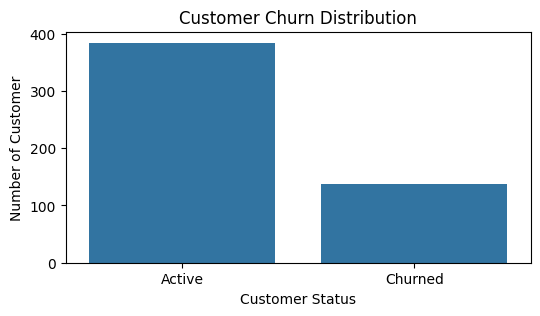

In [117]:
# 1. Customer Churn Distribution
plt.figure(figsize=(6,3))
sns.countplot(data=df, x='churn_flag')
plt.title('Customer Churn Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customer')

plt.xticks([0, 1], ['Active', 'Churned'])
plt.show()

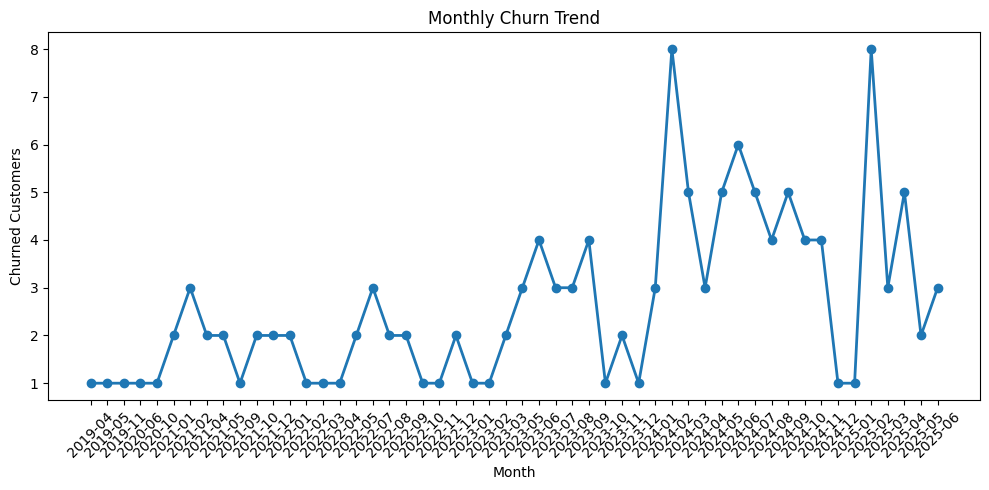

In [118]:
# Monthly Churn Trend 

df['cancellation_month'] = df['cancellation_date'].dt.to_period('M')

churn_trend = (df[df['churn_flag'] == 1].groupby('cancellation_month').size())

plt.figure(figsize=(10, 5))

plt.plot(churn_trend.index.astype(str), churn_trend.values, marker='o', linewidth=2)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

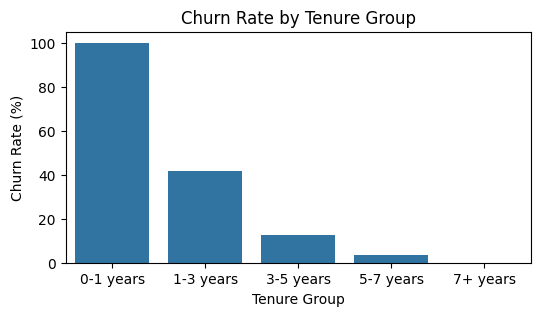

In [119]:
# Churn Rate by Tenure Group
plt.figure(figsize=(6,3))
sns.barplot(data=tenure_analysis, x='tenure_group', y='churn_rate')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')

plt.show()

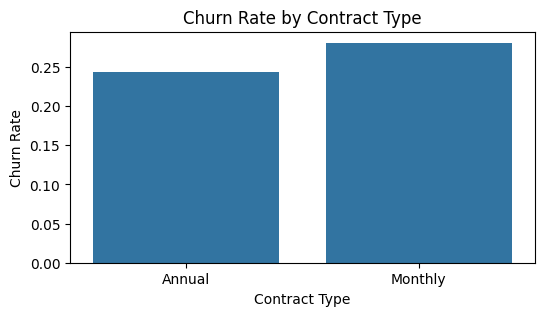

In [120]:
# Churn Rate by Contract Type
plt.figure(figsize=(6, 3))
sns.barplot(data=df, x='contract_type', y='churn_flag', errorbar=None)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')

plt.show()

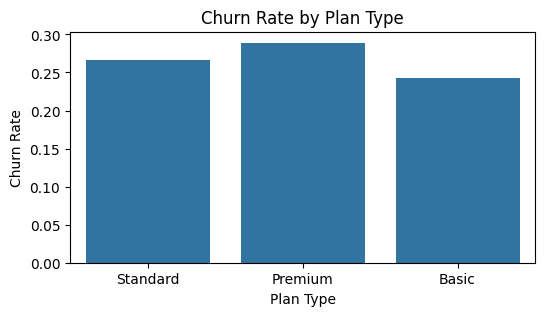

In [121]:
# Churn Rate by Plan Type
plt.figure(figsize=(6, 3))
sns.barplot(data=df, x='plan_type', y='churn_flag', errorbar=None)
plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')

plt.show()

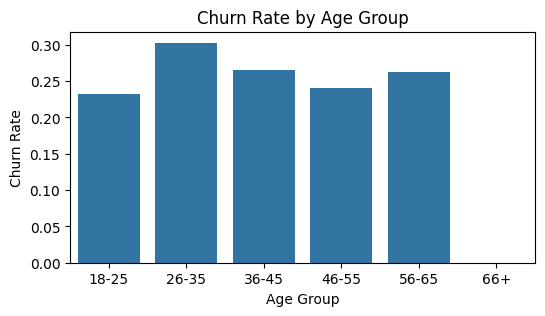

In [122]:
# Churn Rate by Age Group
plt.figure(figsize=(6, 3))

sns.barplot(data=df, x='age_group', y='churn_flag', errorbar=None)

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate')

plt.show()

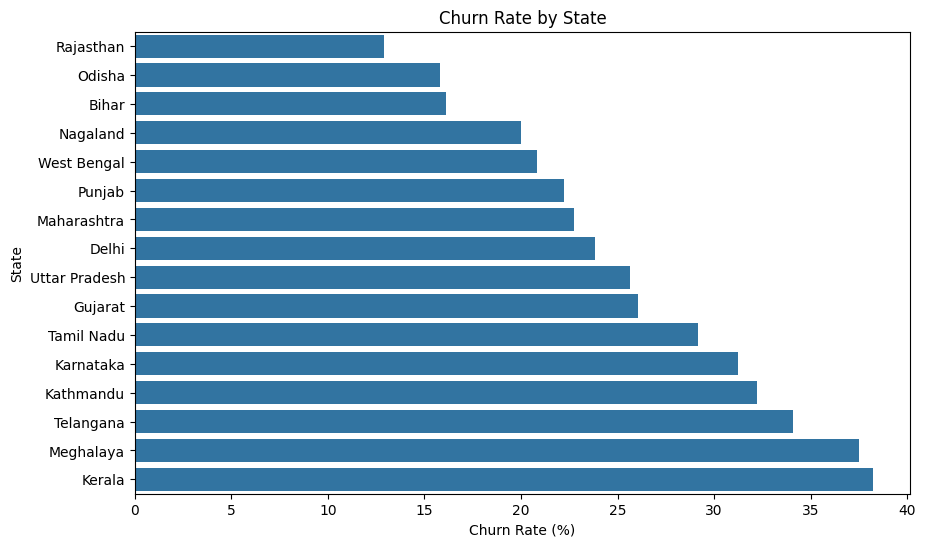

In [123]:
# Churn Rate by State
state_churn = df.groupby('state')['churn_flag'].mean().mul(100).sort_values().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data = state_churn, y='state', x='churn_flag', errorbar=None)
plt.title('Churn Rate by State')
plt.xlabel('Churn Rate (%)')
plt.ylabel('State')

plt.show()

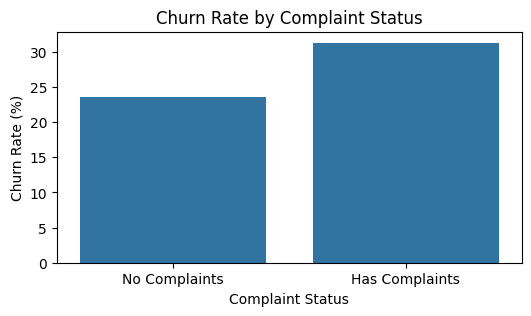

In [124]:
# Complaints vs Churn
complaint_churn = df.groupby(df['complaint_count'] > 0)['churn_flag'].mean().mul(100).reset_index()
complaint_churn['complaint_count'] = complaint_churn['complaint_count'].map({
    False: 'No Complaints',
    True: 'Has Complaints'
})
plt.figure(figsize=(6, 3))

sns.barplot(data=complaint_churn, x='complaint_count', y='churn_flag', errorbar=None)

plt.title('Churn Rate by Complaint Status')
plt.xlabel('Complaint Status')
plt.ylabel('Churn Rate (%)')

plt.show()

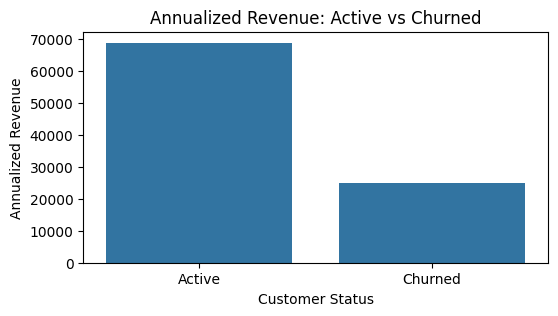

In [125]:
# Annualized Revenue: Active vs Churned
revenue_churn = (
    df.groupby('churn_flag')['annual_charges'].sum().reset_index())

revenue_churn['churn_flag'] = revenue_churn['churn_flag'].map({0: 'Active', 1: 'Churned'})

plt.figure(figsize=(6, 3))

sns.barplot(data=revenue_churn, x='churn_flag', y='annual_charges', errorbar=None)

plt.title('Annualized Revenue: Active vs Churned')
plt.xlabel('Customer Status')
plt.ylabel('Annualized Revenue')

plt.show()

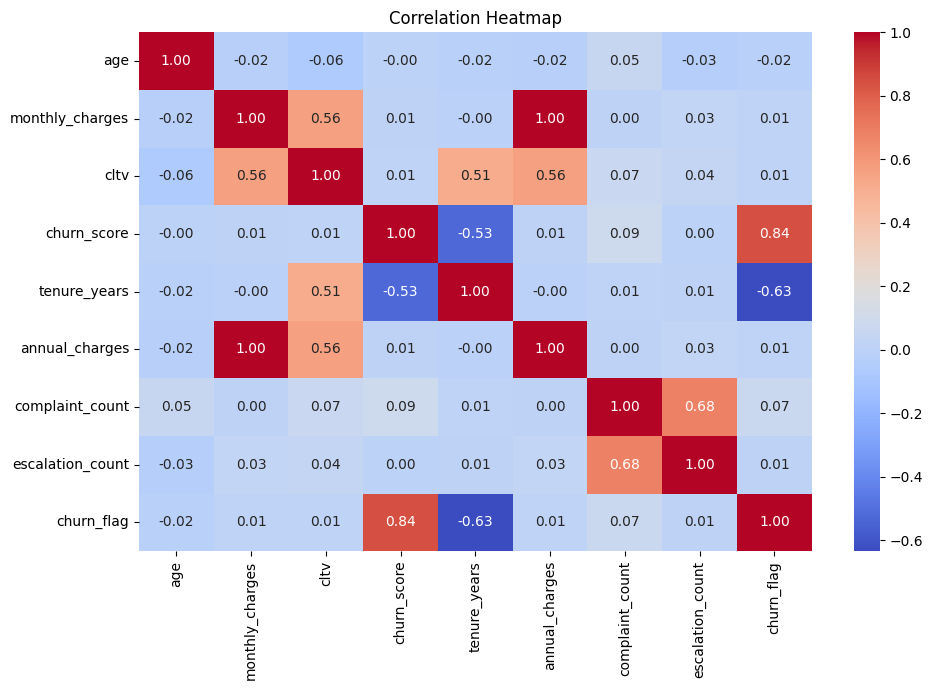

In [126]:
# Correlation Heatmap

corr_columns = [
    'age',
    'monthly_charges',
    'cltv',
    'churn_score',
    'tenure_years',
    'annual_charges',
    'complaint_count',
    'escalation_count',
    'churn_flag'
]

correlation = df[corr_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [127]:
# Pivot Table - Churn by Contract Type

pivot_contract = pd.pivot_table(
    df,
    index='contract_type',
    values='churn_flag',
    aggfunc=['count', 'sum', 'mean']
)

pivot_contract.columns = [
    'Total Customers',
    'Churned Customers',
    'Churn Rate'
]

pivot_contract['Churn Rate'] = (
    pivot_contract['Churn Rate'] * 100
).round(2)

pivot_contract

,Total Customers,Churned Customers,Churn Rate
contract_type,,,
Annual,254,62,24.41
Monthly,267,75,28.09


In [128]:
df_subscription['subscription_type'].unique()

array(['Referral', 'Paid', 'Organic'], dtype=object)